In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from src.shash_torch import Shash
import numpy as np
import torch

In [2]:
model_spec = 'cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'

In [3]:
results = xr.open_dataset(f'results/predictions/{model_spec}/predictions.nc')

In [4]:
target_dir = 'data/processed_data'
slgt_mod_str = '_slgt'
tars = xr.open_dataset(f"{target_dir}/train_targets{slgt_mod_str}_new.nc")

In [5]:
tars

<xarray.Dataset>
Dimensions:      (time: 3414, hazard: 3, variable: 3)
Coordinates:
  * time         (time) datetime64[ns] 2002-04-02 2002-04-03 ... 2019-12-22
  * hazard       (hazard) object 'Wind' 'Hail' 'Tornado'
  * variable     (variable) object 'bias' 'east_shift' 'north_shift'
Data variables:
    bias         (hazard, time) float64 ...
    east_shift   (hazard, time) float64 ...
    north_shift  (hazard, time) float64 ...
    train_mean   (variable, hazard) float64 ...
    train_std    (variable, hazard) float64 ...

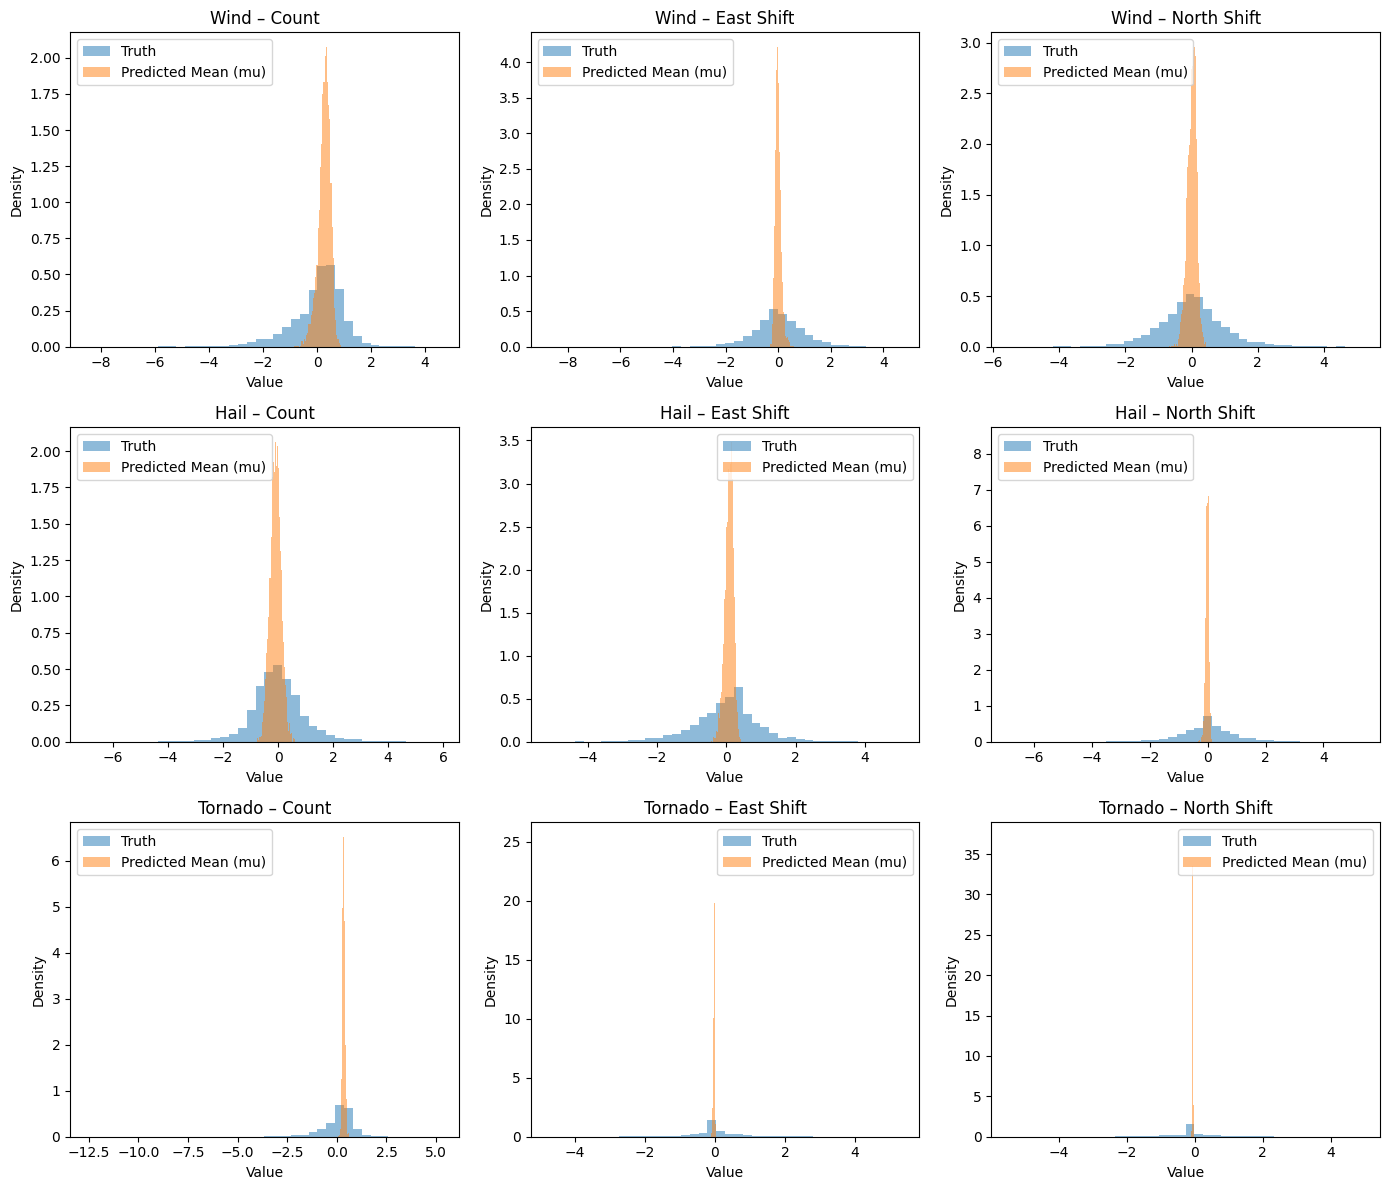

In [6]:
mu = results["mu"].values
truth = results["truth"].values

hazards = ["Wind", "Hail", "Tornado"]
variables = ["Count", "East Shift", "North Shift"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=False, sharey=False)

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):
        k = i * 3 + j  # flattened index
        
        ax = axes[i, j]
        
        ax.hist(truth[:, k], bins=40, density=True, alpha=0.5, label="Truth")
        ax.hist(mu[:, k], bins=40, density=True, alpha=0.5, label="Predicted Mean (mu)")
        
        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.show()

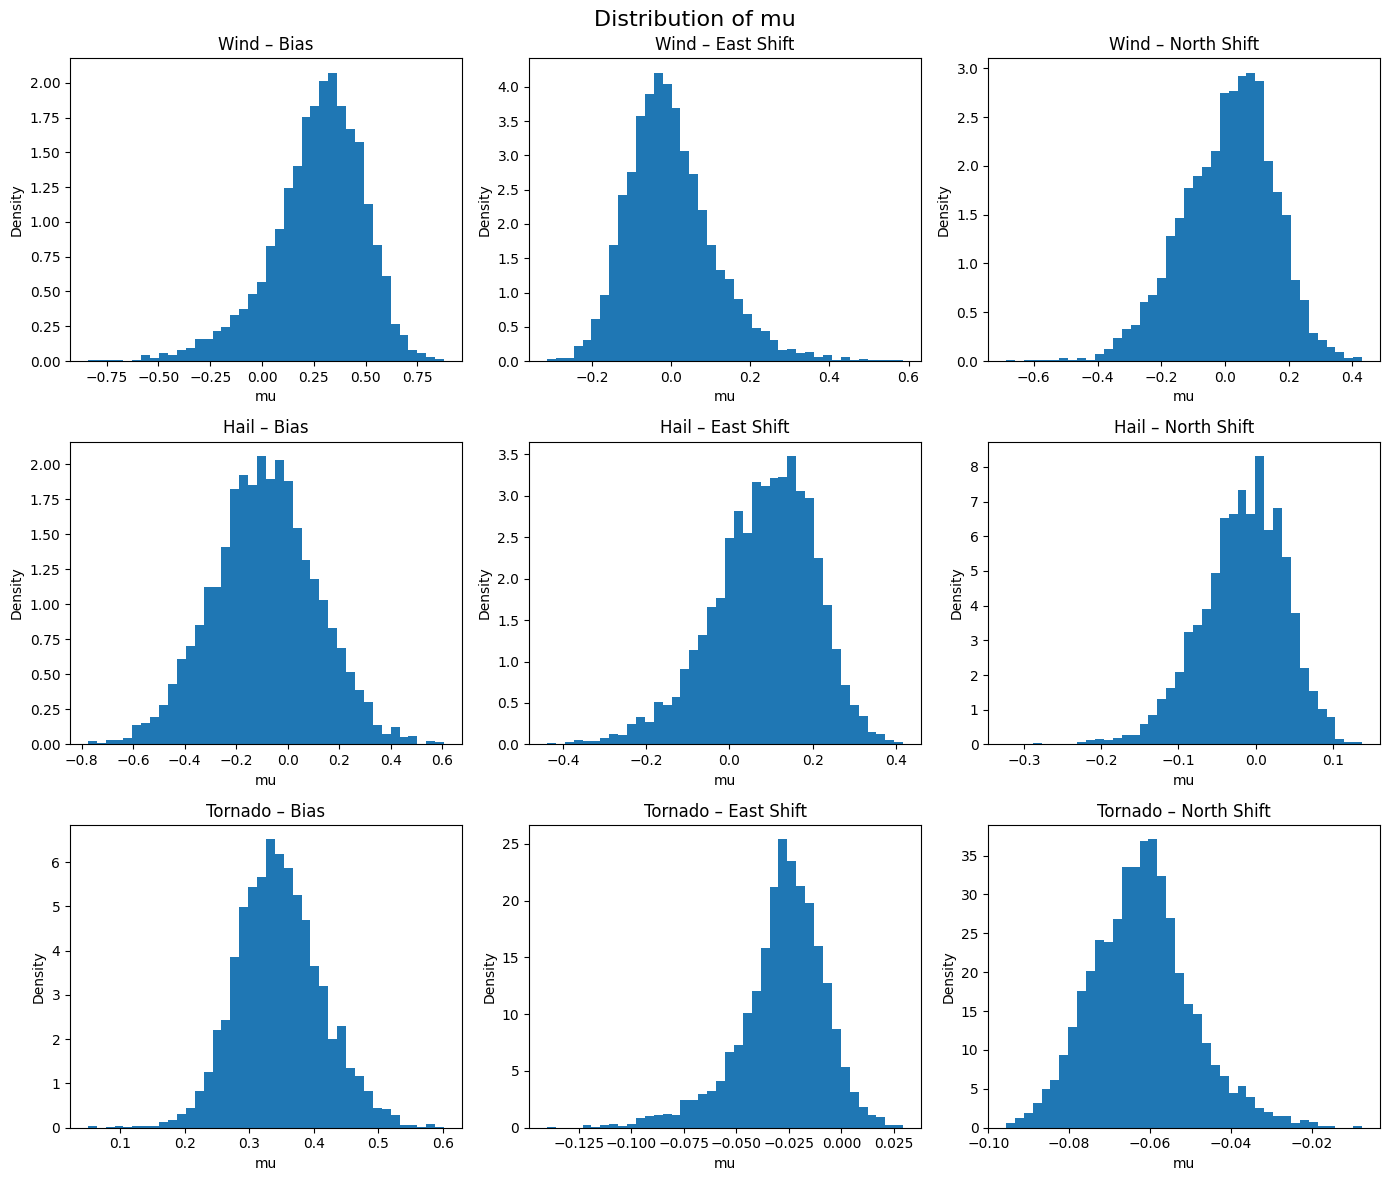

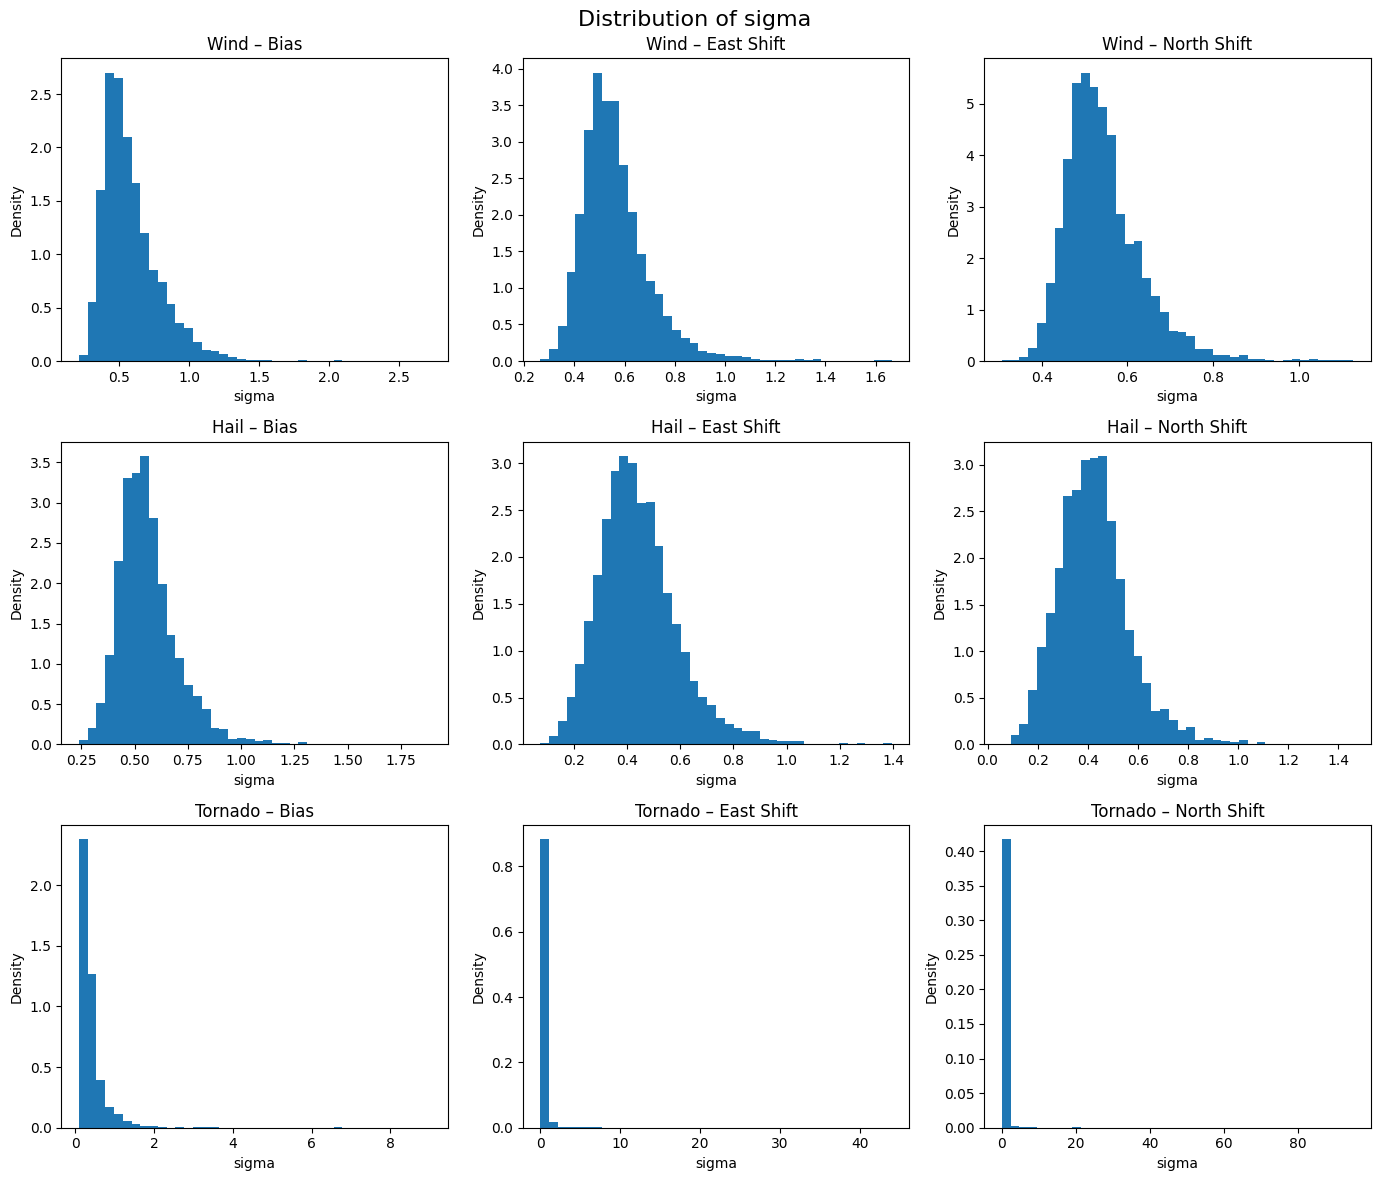

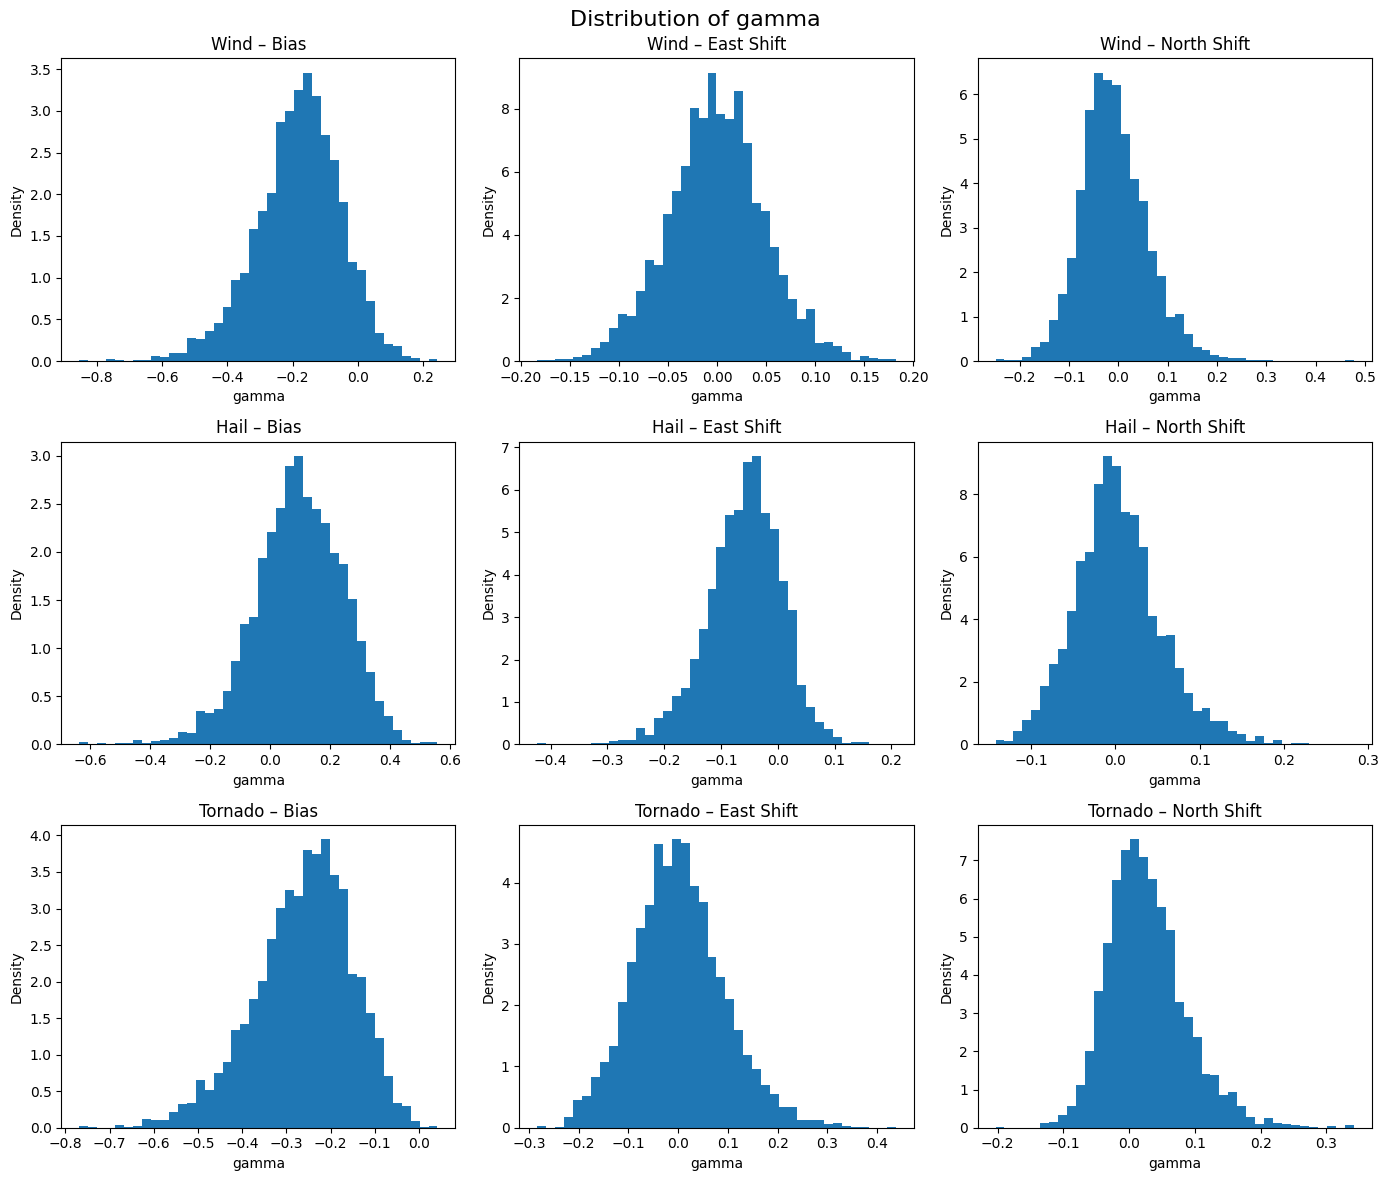

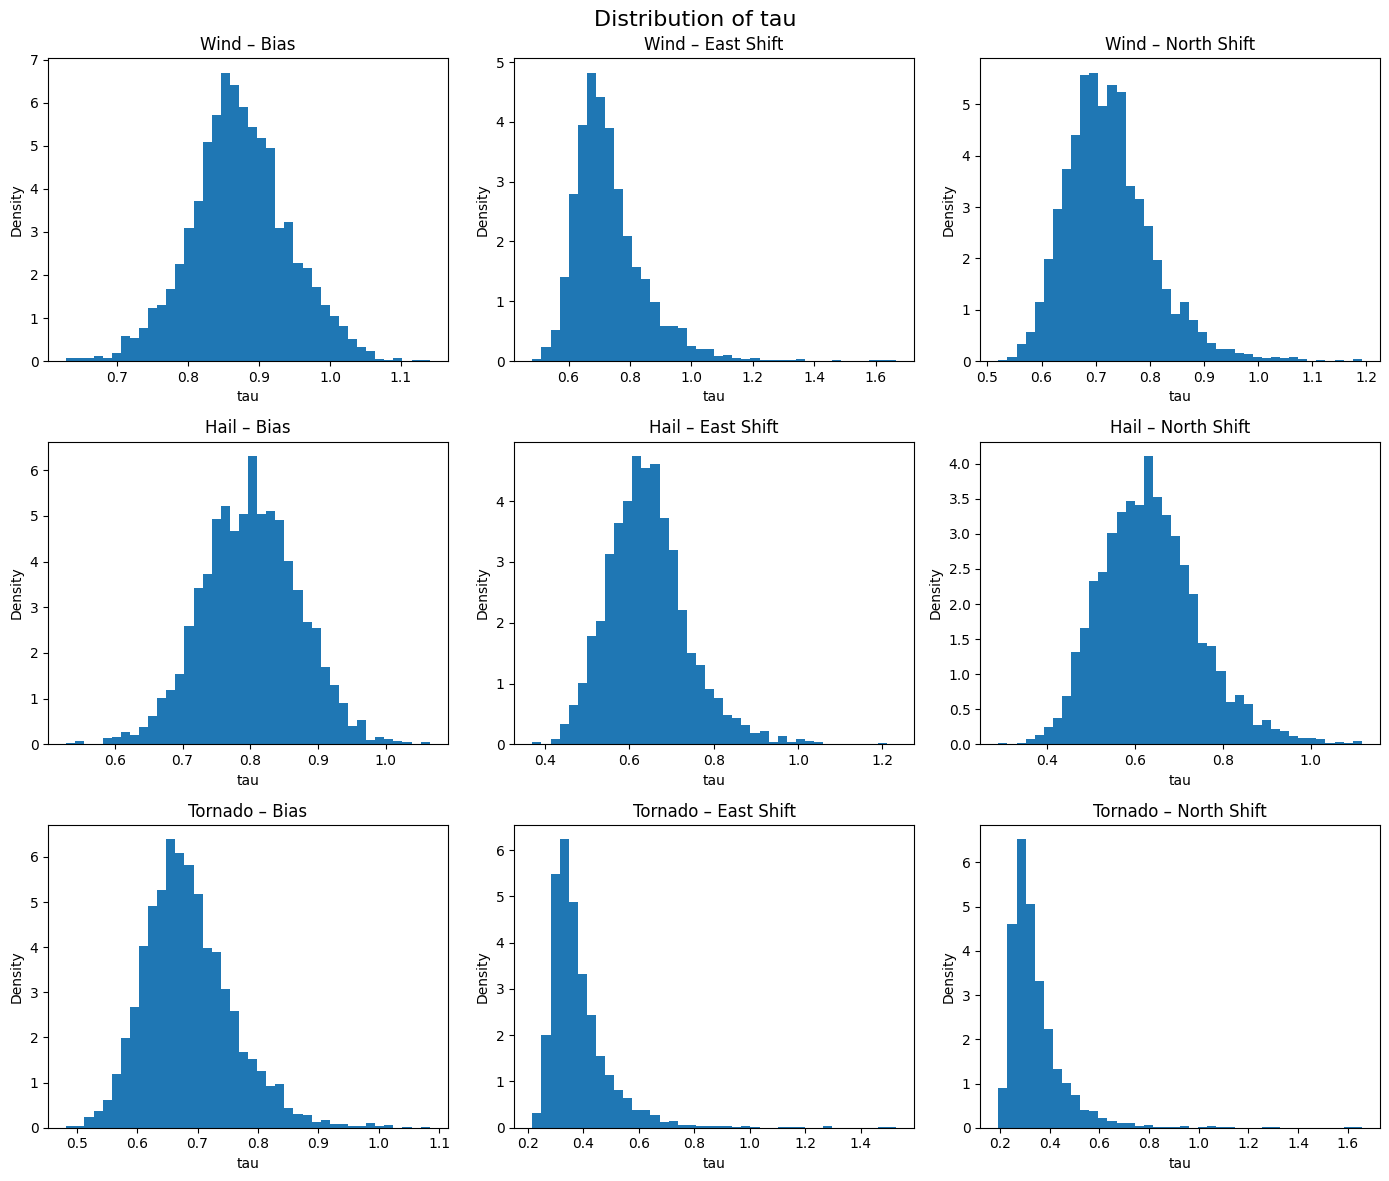

In [7]:
hazards = ["Wind", "Hail", "Tornado"]
variables = ["Bias", "East Shift", "North Shift"]

mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values

param_dict = {
    "mu": mu,
    "sigma": sigma,
    "gamma": gamma,
    "tau": tau
}

for param_name, values in param_dict.items():
    
    fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=False, sharey=False)
    
    for i, hazard in enumerate(hazards):
        for j, var in enumerate(variables):
            k = i * 3 + j  # flattened index
            
            ax = axes[i, j]
            ax.hist(values[:, k], bins=40, density=True)
            
            ax.set_title(f"{hazard} – {var}")
            ax.set_xlabel(param_name)
            ax.set_ylabel("Density")
    
    fig.suptitle(f"Distribution of {param_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

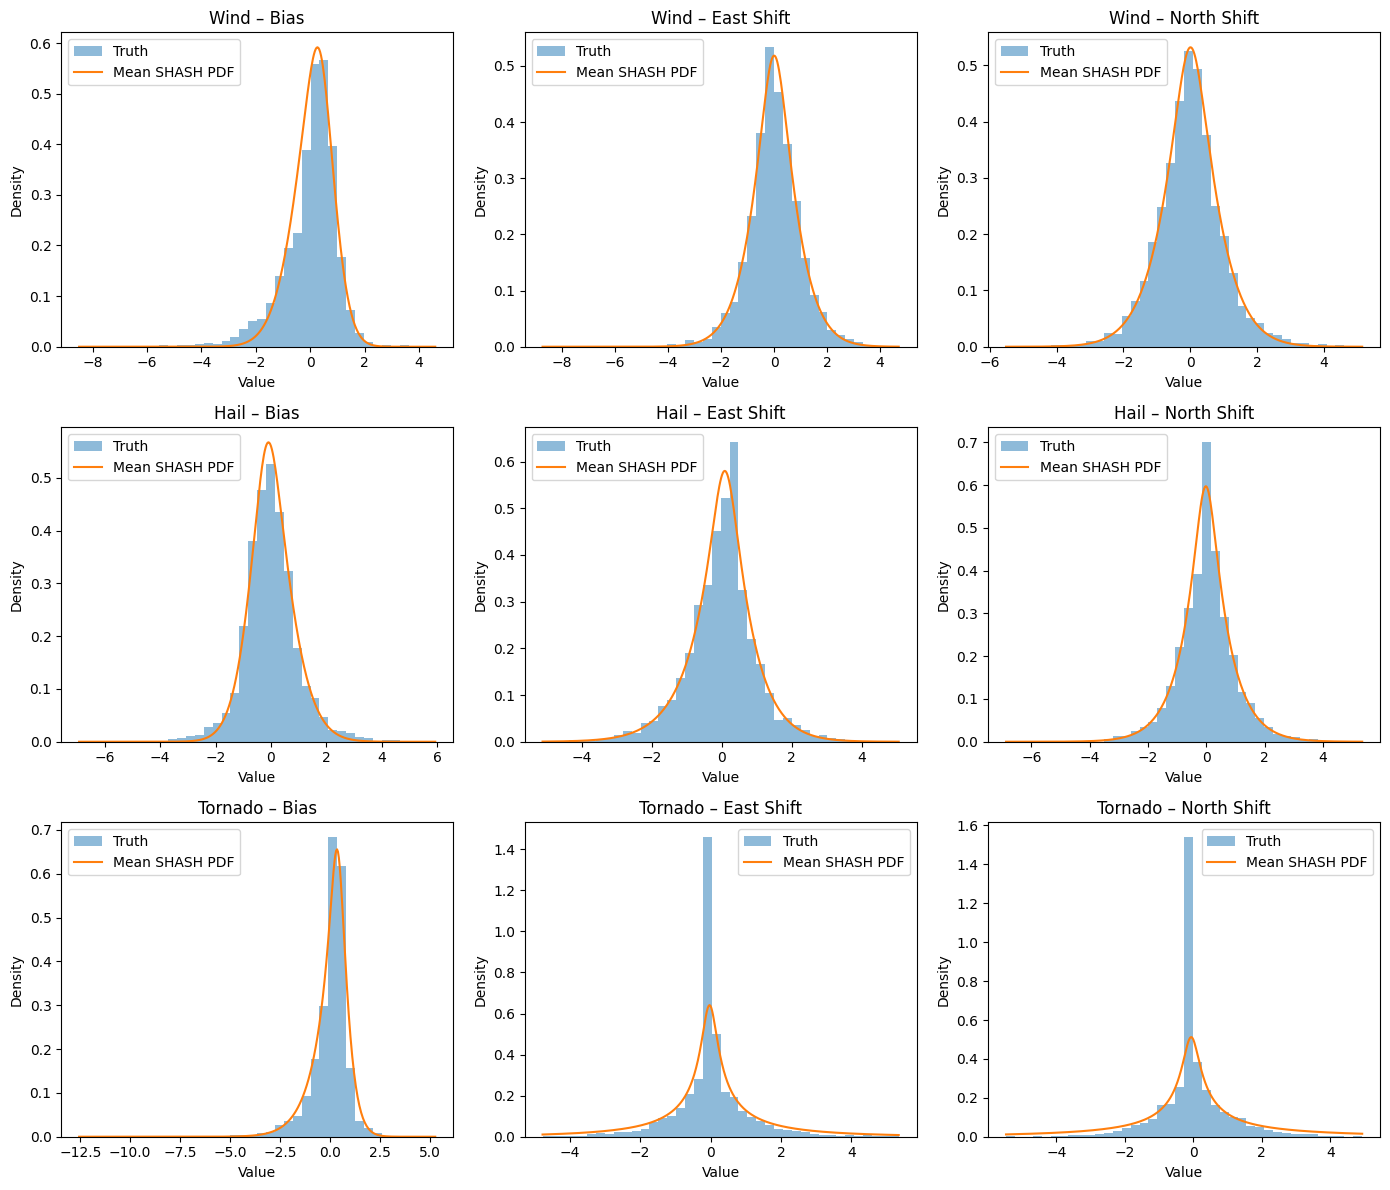

In [8]:
# Extract arrays
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values
truth = results["truth"].values

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):
        k = i * 3 + j
        
        ax = axes[i, j]
        
        # Histogram of truth
        ax.hist(truth[:, k], bins=40, density=True, alpha=0.5, label="Truth")
        
        # Compute mean parameters
        mu_bar = mu[:, k].mean()
        sigma_bar = sigma[:, k].mean()
        gamma_bar = gamma[:, k].mean()
        tau_bar = tau[:, k].mean()
        
        # Build Shash distribution with mean parameters
        params = torch.tensor([[mu_bar, sigma_bar, gamma_bar, tau_bar]])
        dist = Shash(params)
        
        # Create evaluation grid
        x_min = truth[:, k].min()
        x_max = truth[:, k].max()
        x = np.linspace(x_min, x_max, 400)
        
        pdf = dist.prob(torch.tensor(x)).detach().numpy().flatten()
        
        # Overlay PDF
        ax.plot(x, pdf, label="Mean SHASH PDF")
        
        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.show()

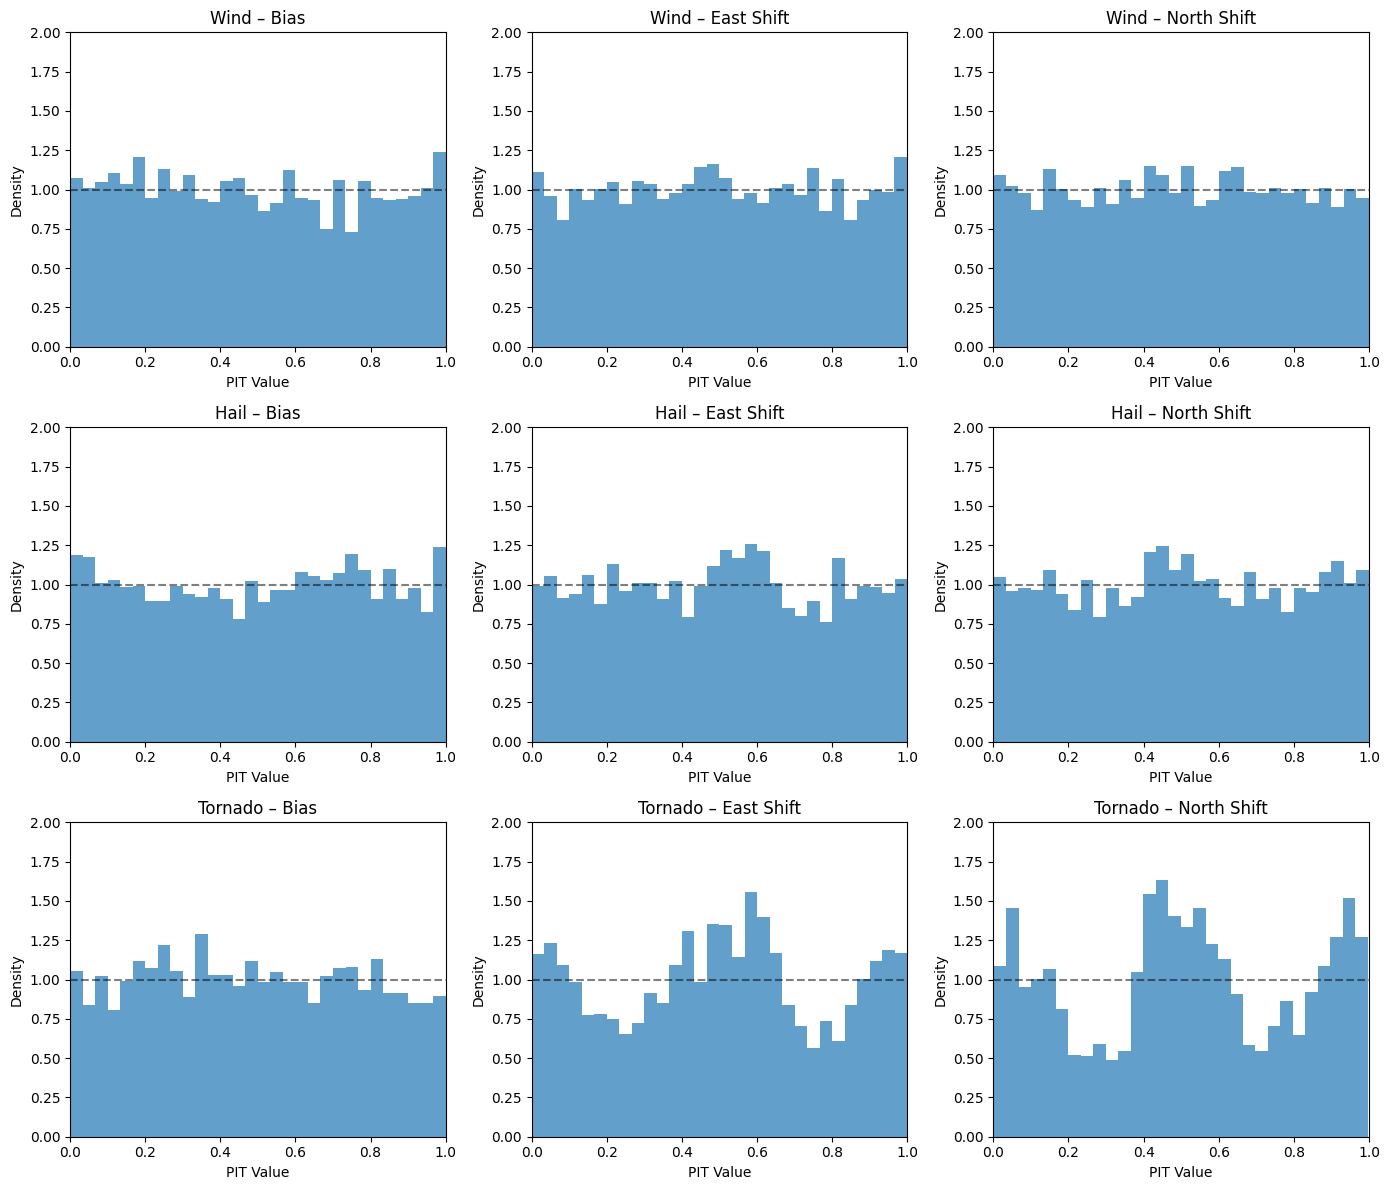

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):

        k = i * 3 + j
        ax = axes[k]

        # Build parameter tensor for SHASH distribution
        params = np.stack([
            mu[:, k],
            sigma[:, k],
            gamma[:, k],
            tau[:, k]
        ], axis=-1)

        shash = Shash(torch.tensor(params))

        # PIT values
        pit_vals = shash.cdf(torch.tensor(truth[:, k])).detach().numpy()

        # Histogram of PIT values
        ax.hist(pit_vals, bins=30, density=True, alpha=0.7)

        ax.plot([0, 1], [1, 1], "k--", alpha=0.5)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 2)
        

        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("PIT Value")
        ax.set_ylabel("Density")

plt.tight_layout()
plt.show()